# 02 · Modelado_V3 — Experimentación Completa

Dataset con desbalance **≈19:1** (95% sin ictus / 5% con ictus).  
Métrica principal: **AUC-ROC** · Métrica secundaria: **Recall** (minimizar falsos negativos).

## Índice
1. Setup e importaciones  
2. Configuración de MLflow  
3. Carga y versiones del dataset  
4. Preprocesado con ColumnTransformer  
5. Pipeline de entrenamiento  
6. Funciones de experimentación (Baseline + Optuna)  
7. Funciones objetivo Optuna  
8. Ejecución de experimentos  
9. Matrices de confusión (orden requerido)  
10. Validación estadística entre modelos  
11. Comparativa de resultados

---
## 01 · Setup e importaciones

Se usa `imblearn.pipeline.Pipeline` — sabe que SMOTE **solo** debe aplicarse durante `fit()`, nunca en `predict()` ni en el test set.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, recall_score,
    f1_score, precision_score, confusion_matrix,
)
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.sklearn

# Tests estadísticos
from scipy.stats import wilcoxon, ttest_ind
from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings("ignore")

# ── Constantes globales ──────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_SPLITS     = 5
N_TRIALS     = 25
AUTHOR       = "Iris"

plt.style.use("seaborn-v0_8-whitegrid")
print("✓ Importaciones completadas")

c:\Users\Coder\Documents\Proyectos-Modulo3\Project_8_Equipo1_DataScientist\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Importaciones completadas


---
## 02 · Configuración de MLflow

Los experimentos se registran localmente en `../mlruns`.  
UI: `mlflow ui --backend-store-uri file:///<ruta_mlruns> --port 5001`

In [28]:
from pathlib import Path

# mlruns_path = os.path.abspath("../mlruns")
# mlflow.set_tracking_uri(f"file:///{mlruns_path}")

# # ── MODIFICADO: dos experimentos separados ──
# EXPERIMENT_TRAINING = "stroke_project"   # todos los 24 runs
# EXPERIMENT_BEST     = "ictus_project"    # solo los 3 mejores

# mlflow.set_experiment(EXPERIMENT_TRAINING)  # activo por defecto al entrenar

# BASE_DIR      = Path().resolve().parent
# assets_dir    = BASE_DIR / "assets"
# assets_v3_dir = assets_dir / "v3"
# assets_dir.mkdir(parents=True, exist_ok=True)
# assets_v3_dir.mkdir(parents=True, exist_ok=True)

# print(f"✓ Experimento entrenamiento : {EXPERIMENT_TRAINING}")
# print(f"✓ Experimento mejores       : {EXPERIMENT_BEST}")
# print(f"✓ Assets dir : {assets_dir}")
# print(f"✓ Assets v3  : {assets_v3_dir}")

mlruns_path = os.path.abspath("../mlruns")
mlflow.set_tracking_uri(f"file:///{mlruns_path}")
print(f"✓ MLflow usando carpeta compartida: {mlruns_path}")

EXPERIMENT_NAME = "Ictus_Project"
mlflow.set_experiment(EXPERIMENT_NAME)

BASE_DIR   = Path().resolve().parent
assets_dir = BASE_DIR / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)

print(f"✓ Experimento MLflow: {EXPERIMENT_NAME}")
print(f"✓ Assets dir: {assets_dir}")

✓ MLflow usando carpeta compartida: c:\Users\Coder\Documents\Proyectos-Modulo3\Project_8_Equipo1_DataScientist\mlruns
✓ Experimento MLflow: Ictus_Project
✓ Assets dir: C:\Users\Coder\Documents\Proyectos-Modulo3\Project_8_Equipo1_DataScientist\assets


---
## 03 · Carga y versiones del dataset

- **full** → todos los pacientes (incluye menores de 16 años)
- **adults** → solo pacientes con `age > 16`

In [3]:
df = pd.read_csv("../data/raw/stroke_dataset.csv")
print(f"✓ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Stroke=1 : {df['stroke'].sum()} ({df['stroke'].mean()*100:.1f}%)")
print(f"  Stroke=0 : {(df['stroke']==0).sum()} ({(1-df['stroke'].mean())*100:.1f}%)")

✓ Dataset cargado: 4,981 filas × 11 columnas
  Stroke=1 : 248 (5.0%)
  Stroke=0 : 4733 (95.0%)


In [4]:
def get_dataset(version: str = "full") -> pd.DataFrame:
    assert version in ("full", "adults"), f"version debe ser 'full' o 'adults', recibido: {version}"

    df_copy = df.copy()

    df_copy.loc[df_copy["work_type"] == "children", "work_type"] = "not_applied"

    df_copy.loc[(df_copy["age"] <= 16) & (df_copy["smoking_status"] == "Unknown"), "smoking_status"] = "not_applied"

    df_copy["group"] = df_copy["age"].apply(lambda x: "children" if x <= 16 else "adult")

    if version == "adults":
        df_copy = df_copy[df_copy["age"] > 16]
        df_copy = df_copy.drop(columns=["group"])

    print(f"✓ Dataset '{version}': {df_copy.shape[0]:,} filas")
    return df_copy


# Pre-carga para visualización rápida
_ = get_dataset("full")
_ = get_dataset("adults")

✓ Dataset 'full': 4,981 filas
✓ Dataset 'adults': 4,211 filas


---
## 04 · Preprocesado con ColumnTransformer

- **Numéricas → StandardScaler**: centra en media 0 y escala a desviación 1.
- **Categóricas → OneHotEncoder**: `handle_unknown='ignore'` evita errores en producción.
- El fit aprende SOLO del conjunto de entrenamiento.

In [5]:
def build_preprocessor(X_train: pd.DataFrame) -> ColumnTransformer:
    cat_cols = X_train.select_dtypes(include="object").columns.tolist()
    num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

    return ColumnTransformer([
        ("num", StandardScaler(),                       num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])


print("✓ build_preprocessor definido")

✓ build_preprocessor definido


---
## 05 · Pipeline de entrenamiento

El Pipeline de imblearn encadena: `prep → [smote] → model`.  
Durante `predict()`, SMOTE no se ejecuta — garantiza que el test set **nunca** se modifique.

In [6]:
def build_pipeline(model, preprocessor: ColumnTransformer, use_smote: bool = False) -> Pipeline:
    steps = [("prep", preprocessor)]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)


print("✓ build_pipeline definido")

✓ build_pipeline definido


---
## 06 · Funciones de experimentación

### 06.1 · Función auxiliar de evaluación

In [7]:
def evaluate_pipeline(pipeline, X_test, y_test) -> tuple:
    """Evalúa el pipeline y retorna (y_pred, y_prob, métricas)."""
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "auc":       round(roc_auc_score(y_test, y_prob), 4),
        "recall":    round(recall_score(y_test, y_pred),  4),
        "f1":        round(f1_score(y_test, y_pred),      4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
    }
    return y_pred, y_prob, metrics


def log_confusion_matrix(pipeline, X_test, y_test, title: str, save_path: str) -> None:
    """Genera, guarda y loguea en MLflow la matriz de confusión."""
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Stroke", "Stroke"],
        yticklabels=["No Stroke", "Stroke"], ax=ax
    )
    ax.set_title(title)
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.close()
    mlflow.log_artifact(save_path)


print("✓ Funciones auxiliares definidas")

✓ Funciones auxiliares definidas


### 06.2 · Función `run_experiment` (Baseline)

In [8]:
def run_experiment(
    model,
    model_name: str,
    dataset_version: str = "full",
    use_smote: bool = False,
    author: str = AUTHOR,
) -> dict:
    """
    Entrena un modelo baseline y registra en MLflow.

    Parámetros
    ----------
    model           : estimador sklearn
    model_name      : nombre del run en MLflow
    dataset_version : 'full' o 'adults'
    use_smote       : si True aplica SMOTE solo en train
    author          : nombre del autor

    Retorna
    -------
    dict con métricas del experimento
    """
    print(f"\n{'='*65}")
    print(f"  {model_name} | dataset={dataset_version} | SMOTE={use_smote}")
    print(f"{'='*65}")

    df_exp = get_dataset(dataset_version)
    X = df_exp.drop("stroke", axis=1)
    y = df_exp["stroke"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"  Train: {len(X_train):,} | Test: {len(X_test):,} | Stroke train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")

    preprocessor = build_preprocessor(X_train)
    pipeline     = build_pipeline(model, preprocessor, use_smote)

    run_name = f"{author}_{model_name}_{dataset_version}_smote={use_smote}"

    with mlflow.start_run(run_name=run_name, experiment_id=mlflow.get_experiment_by_name(EXPERIMENT_TRAINING).experiment_id):
        pipeline.fit(X_train, y_train)
        y_pred, y_prob, metrics = evaluate_pipeline(pipeline, X_test, y_test)

        # ── NUEVO: evaluación en train para detectar overfitting ──
        _, _, metrics_train = evaluate_pipeline(pipeline, X_train, y_train)
        diff_auc    = metrics_train["auc"]    - metrics["auc"]
        diff_recall = metrics_train["recall"] - metrics["recall"]
        diff_f1     = metrics_train["f1"]     - metrics["f1"]
        # ─────────────────────────────────────────────────────────

        mlflow.log_metrics(metrics)

        # ── NUEVO: loguear diferencias ────────────────────────────
        mlflow.log_metric("overfitting_diff_auc",    round(diff_auc,    4))
        mlflow.log_metric("overfitting_diff_recall", round(diff_recall, 4))
        mlflow.log_metric("overfitting_diff_f1",     round(diff_f1,     4))
        # ─────────────────────────────────────────────────────────

        mlflow.log_params(model.get_params())
        mlflow.set_tags({
            "author": author,
            "dataset_version": dataset_version,
            "use_smote": str(use_smote),
            "model_type": model_name,
            "optimization": "baseline",
        })
        mlflow.sklearn.log_model(pipeline, artifact_path=model_name)

        cm_path = str(assets_v3_dir / f"cm_{model_name}_baseline_{dataset_version}_smote={use_smote}.png")
        log_confusion_matrix(
            pipeline, X_test, y_test,
            title=f"{model_name} Baseline | {dataset_version} | SMOTE={use_smote}",
            save_path=cm_path
        )

        print(f"  AUC-ROC   : {metrics['auc']:.4f}  ← métrica principal")
        print(f"  Recall    : {metrics['recall']:.4f}  ← minimizar falsos negativos")
        print(f"  F1-score  : {metrics['f1']:.4f}")
        print(f"  Precision : {metrics['precision']:.4f}")
        # ── NUEVO: print overfitting ──────────────────────────────
        print(f"  Overfit ΔAuc   : {diff_auc:+.4f}  (train-test)")
        print(f"  Overfit ΔRecall: {diff_recall:+.4f}  (train-test)")
        print(f"  Overfit ΔF1    : {diff_f1:+.4f}  (train-test)")
        # ─────────────────────────────────────────────────────────
        
        print(f"  ✓ Run registrado → {run_name}")

    overfit = {
        "overfitting_diff_auc":    round(diff_auc,    4),
        "overfitting_diff_recall": round(diff_recall, 4),
        "overfitting_diff_f1":     round(diff_f1,     4)
    }

    return {
        "modelo": model_name, "dataset": dataset_version,
        "smote": use_smote,   "tipo": "baseline",
        **overfit,
        **metrics,
    }


print("✓ run_experiment definido")

✓ run_experiment definido


### 06.3 · Función `run_optuna_experiment`

In [9]:
def get_best_model(model_name: str, best_params: dict):
    """Reconstruye el modelo con los mejores parámetros de Optuna."""
    if model_name == "LogisticRegression":
        return LogisticRegression(
            **best_params, class_weight="balanced",
            max_iter=1000, random_state=RANDOM_STATE,
        )
    elif model_name == "RandomForest":
        return RandomForestClassifier(
            **best_params, class_weight="balanced", random_state=RANDOM_STATE,
        )
    elif model_name == "XGBoost":
        return XGBClassifier(
            **best_params, scale_pos_weight=19,
            eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0,
        )

trained_pipelines = {}  # guarda los pipelines Optuna entrenados

def run_optuna_experiment(
    model_name: str,
    dataset_version: str = "full",
    use_smote: bool = False,
    n_trials: int = N_TRIALS,
    author: str = AUTHOR,
) -> dict:
    """
    Busca los mejores hiperparámetros con Optuna y registra en MLflow.

    Parámetros
    ----------
    model_name      : 'LogisticRegression', 'RandomForest', 'XGBoost'
    dataset_version : 'full' o 'adults'
    use_smote       : si True aplica SMOTE solo en train
    n_trials        : número de trials Optuna
    author          : nombre del autor

    Retorna
    -------
    dict con métricas del experimento optimizado
    """
    print(f"\n{'='*65}")
    print(f"  [OPTUNA] {model_name} | dataset={dataset_version} | SMOTE={use_smote}")
    print(f"{'='*65}")

    df_exp = get_dataset(dataset_version)
    X = df_exp.drop("stroke", axis=1)
    y = df_exp["stroke"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    objective_fn = OBJECTIVES[model_name] #type: ignore
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        lambda trial: objective_fn(trial, X_train, y_train, use_smote),
        n_trials=n_trials,
        show_progress_bar=False,
    )

    best_params = study.best_params
    print(f"  Mejores parámetros: {best_params}")
    print(f"  Mejor AUC-CV: {study.best_value:.4f}")

    best_model   = get_best_model(model_name, best_params)
    preprocessor = build_preprocessor(X_train)
    pipeline     = build_pipeline(best_model, preprocessor, use_smote)

    run_name = f"{author}_{model_name}_optuna_{dataset_version}_smote={use_smote}"

    with mlflow.start_run(run_name=run_name, experiment_id=mlflow.get_experiment_by_name(EXPERIMENT_TRAINING).experiment_id):
        pipeline.fit(X_train, y_train)

        # ── NUEVO: guardar pipeline entrenado ────────────────────────
        pipeline_key = f"{model_name}_{dataset_version}_smote={use_smote}"
        trained_pipelines[pipeline_key] = {
        "pipeline": pipeline,
        "X_test":   X_test,
        "y_test":   y_test,
        }
        # ─────────────────────────────────────────────────────────────
        
        y_pred, y_prob, metrics = evaluate_pipeline(pipeline, X_test, y_test)

        # ── NUEVO ─────────────────────────────────────────────────
        _, _, metrics_train = evaluate_pipeline(pipeline, X_train, y_train)
        diff_auc    = metrics_train["auc"]    - metrics["auc"]
        diff_recall = metrics_train["recall"] - metrics["recall"]
        diff_f1     = metrics_train["f1"]     - metrics["f1"]
        # ─────────────────────────────────────────────────────────

        mlflow.log_metrics(metrics)
        mlflow.log_metric("optuna_best_cv_auc", round(study.best_value, 4))

        # ── NUEVO ─────────────────────────────────────────────────
        mlflow.log_metric("overfitting_diff_auc",    round(diff_auc,    4))
        mlflow.log_metric("overfitting_diff_recall", round(diff_recall, 4))
        mlflow.log_metric("overfitting_diff_f1",     round(diff_f1,     4))
       # ─────────────────────────────────────────────────────────

        mlflow.log_params(best_params)
        mlflow.log_param("n_trials", n_trials)
        mlflow.set_tags({
            "author": author,
            "dataset_version": dataset_version,
            "use_smote": str(use_smote),
            "model_type": model_name,
            "optimization": "optuna",
        })
        mlflow.sklearn.log_model(pipeline, artifact_path=f"{model_name}_optuna")

        cm_path = str(assets_v3_dir / f"cm_{model_name}_optuna_{dataset_version}_smote={use_smote}.png")
        log_confusion_matrix(
            pipeline, X_test, y_test,
            title=f"{model_name} Optuna | {dataset_version} | SMOTE={use_smote}",
            save_path=cm_path
        )

        print(f"  AUC-ROC   : {metrics['auc']:.4f}  ← métrica principal")
        print(f"  Recall    : {metrics['recall']:.4f}  ← minimizar falsos negativos")
        print(f"  F1-score  : {metrics['f1']:.4f}")
        print(f"  Precision : {metrics['precision']:.4f}")
        # ── NUEVO: print overfitting ──────────────────────────────
        print(f"  Overfit ΔAuc   : {diff_auc:+.4f}  (train-test)")
        print(f"  Overfit ΔRecall: {diff_recall:+.4f}  (train-test)")
        print(f"  Overfit ΔF1    : {diff_f1:+.4f}  (train-test)")
        # ─────────────────────────────────────────────────────────
        print(f"  ✓ Run Optuna registrado → {run_name}")

    overfit = {
        "overfitting_diff_auc":    round(diff_auc,    4),
        "overfitting_diff_recall": round(diff_recall, 4),
        "overfitting_diff_f1":     round(diff_f1,     4)
    }

    return {
        "modelo": model_name, "dataset": dataset_version,
        "smote": use_smote,   "tipo": "optuna",
        **overfit,
        **metrics,
    }


print("✓ run_optuna_experiment definido")

✓ run_optuna_experiment definido


---
## 07 · Funciones objetivo Optuna

Se optimiza AUC-ROC con `StratifiedKFold(n_splits=5)` dentro de cada trial.

In [10]:
def objective_lr(trial, X_train, y_train, use_smote: bool) -> float:
    params = {
        "C":      trial.suggest_float("C", 0.001, 10.0, log=True),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
    }
    model = LogisticRegression(
        **params, class_weight="balanced",
        max_iter=1000, random_state=RANDOM_STATE
    )
    preprocessor = build_preprocessor(X_train)
    pipeline = build_pipeline(model, preprocessor, use_smote)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(pipeline, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1).mean()


def objective_rf(trial, X_train, y_train, use_smote: bool) -> float:
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
    }
    model = RandomForestClassifier(
        **params, class_weight="balanced", random_state=RANDOM_STATE
    )
    preprocessor = build_preprocessor(X_train)
    pipeline = build_pipeline(model, preprocessor, use_smote)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(pipeline, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1).mean()


def objective_xgb(trial, X_train, y_train, use_smote: bool) -> float:
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 50, 300),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    model = XGBClassifier(
        **params, scale_pos_weight=19, eval_metric="logloss",
        random_state=RANDOM_STATE, verbosity=0
    )
    preprocessor = build_preprocessor(X_train)
    pipeline = build_pipeline(model, preprocessor, use_smote)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(pipeline, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1).mean()


OBJECTIVES = {
    "LogisticRegression": objective_lr,
    "RandomForest":       objective_rf,
    "XGBoost":            objective_xgb,
}

print("✓ Funciones objetivo Optuna definidas (LR, RF, XGBoost)")

✓ Funciones objetivo Optuna definidas (LR, RF, XGBoost)


---
## 08 · Ejecución de experimentos

**Matriz de experimentos:**  
`3 modelos × 2 datasets × 2 SMOTE × 2 tipos = 24 experimentos`

### 08.1 · Definición de modelos baseline

In [11]:
def get_baseline_models() -> dict:
    """Retorna los modelos baseline con parámetros por defecto razonables."""
    return {
        "LogisticRegression": LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=100, scale_pos_weight=19, eval_metric="logloss",
            random_state=RANDOM_STATE, verbosity=0,
        ),
    }

print("✓ Modelos baseline definidos:")
for name in get_baseline_models():
    print(f"  · {name}")

✓ Modelos baseline definidos:
  · LogisticRegression
  · RandomForest
  · XGBoost


### 08.2 · Experimentos Baseline

In [12]:
results = []

for dataset_version in ["full", "adults"]:
    for use_smote in [True, False]:
        for model_name, model in get_baseline_models().items():
            res = run_experiment(
                model=model,
                model_name=model_name,
                dataset_version=dataset_version,
                use_smote=use_smote,
                author=AUTHOR,
            )
            results.append(res)

print(f"\n✓ Baseline completado: {len(results)} experimentos")


  LogisticRegression | dataset=full | SMOTE=True
✓ Dataset 'full': 4,981 filas
  Train: 3,984 | Test: 997 | Stroke train: 198 (5.0%)


2026/04/23 09:44:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 09:44:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.8372  ← métrica principal
  Recall    : 0.7800  ← minimizar falsos negativos
  F1-score  : 0.2371
  Precision : 0.1398
  Overfit ΔAuc   : +0.0075  (train-test)
  Overfit ΔRecall: +0.0331  (train-test)
  Overfit ΔF1    : +0.0023  (train-test)
  ✓ Run registrado → Iris_LogisticRegression_full_smote=True

  RandomForest | dataset=full | SMOTE=True
✓ Dataset 'full': 4,981 filas
  Train: 3,984 | Test: 997 | Stroke train: 198 (5.0%)


2026/04/23 09:44:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 09:44:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.8063  ← métrica principal
  Recall    : 0.1000  ← minimizar falsos negativos
  F1-score  : 0.1124
  Precision : 0.1282
  Overfit ΔAuc   : +0.1937  (train-test)
  Overfit ΔRecall: +0.9000  (train-test)
  Overfit ΔF1    : +0.8876  (train-test)
  ✓ Run registrado → Iris_RandomForest_full_smote=True

  XGBoost | dataset=full | SMOTE=True
✓ Dataset 'full': 4,981 filas
  Train: 3,984 | Test: 997 | Stroke train: 198 (5.0%)


...

  AUC-ROC   : 0.8332  ← métrica principal
  Recall    : 0.8163  ← minimizar falsos negativos
  F1-score  : 0.2500
  Precision : 0.1476
  Overfit ΔAuc   : -0.0136  (train-test)
  Overfit ΔRecall: -0.0244  (train-test)
  Overfit ΔF1    : -0.0016  (train-test)
  ✓ Run registrado → Iris_LogisticRegression_adults_smote=False

  RandomForest | dataset=adults | SMOTE=False
✓ Dataset 'adults': 4,211 filas
  Train: 3,368 | Test: 843 | Stroke train: 197 (5.8%)


2026/04/23 09:49:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 09:49:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.7619  ← métrica principal
  Recall    : 0.0000  ← minimizar falsos negativos
  F1-score  : 0.0000
  Precision : 0.0000
  Overfit ΔAuc   : +0.2381  (train-test)
  Overfit ΔRecall: +1.0000  (train-test)
  Overfit ΔF1    : +1.0000  (train-test)
  ✓ Run registrado → Iris_RandomForest_adults_smote=False

  XGBoost | dataset=adults | SMOTE=False
✓ Dataset 'adults': 4,211 filas
  Train: 3,368 | Test: 843 | Stroke train: 197 (5.8%)


2026/04/23 09:49:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 09:49:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.7607  ← métrica principal
  Recall    : 0.1633  ← minimizar falsos negativos
  F1-score  : 0.1684
  Precision : 0.1739
  Overfit ΔAuc   : +0.2393  (train-test)
  Overfit ΔRecall: +0.8367  (train-test)
  Overfit ΔF1    : +0.8093  (train-test)
  ✓ Run registrado → Iris_XGBoost_adults_smote=False

✓ Baseline completado: 12 experimentos


### 08.3 · Experimentos Optuna

In [13]:
model_names = ["LogisticRegression", "RandomForest", "XGBoost"]

for dataset_version in ["full", "adults"]:
    for use_smote in [True, False]:
        for model_name in model_names:
            res = run_optuna_experiment(
                model_name=model_name,
                dataset_version=dataset_version,
                use_smote=use_smote,
                n_trials=N_TRIALS,
                author=AUTHOR,
            )
            results.append(res)

print(f"\n✓ Todos los experimentos completados: {len(results)} runs totales")


  [OPTUNA] LogisticRegression | dataset=full | SMOTE=True
✓ Dataset 'full': 4,981 filas
  Mejores parámetros: {'C': 0.00541524411940254, 'solver': 'liblinear'}
  Mejor AUC-CV: 0.8376


2026/04/23 09:51:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 09:51:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.8410  ← métrica principal
  Recall    : 0.8200  ← minimizar falsos negativos
  F1-score  : 0.2440
  Precision : 0.1434
  Overfit ΔAuc   : +0.0044  (train-test)
  Overfit ΔRecall: +0.0032  (train-test)
  Overfit ΔF1    : -0.0088  (train-test)
  ✓ Run Optuna registrado → Iris_LogisticRegression_optuna_full_smote=True

  [OPTUNA] RandomForest | dataset=full | SMOTE=True
✓ Dataset 'full': 4,981 filas
  Mejores parámetros: {'n_estimators': 243, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 10}
  Mejor AUC-CV: 0.7996


2026/04/23 09:54:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 09:54:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.8185  ← métrica principal
  Recall    : 0.3800  ← minimizar falsos negativos
  F1-score  : 0.2135
  Precision : 0.1484
  Overfit ΔAuc   : +0.1100  (train-test)
  Overfit ΔRecall: +0.3271  (train-test)
  Overfit ΔF1    : +0.2173  (train-test)
  ✓ Run Optuna registrado → Iris_RandomForest_optuna_full_smote=True

  [OPTUNA] XGBoost | dataset=full | SMOTE=True
✓ Dataset 'full': 4,981 filas
  Mejores parámetros: {'n_estimators': 127, 'max_depth': 3, 'learning_rate': 0.019103577788653178, 'subsample': 0.5610144978997246, 'colsample_bytree': 0.9072226176099981}
  Mejor AUC-CV: 0.7959


...

  AUC-ROC   : 0.8304  ← métrica principal
  Recall    : 0.7959  ← minimizar falsos negativos
  F1-score  : 0.2371
  Precision : 0.1393
  Overfit ΔAuc   : -0.0117  (train-test)
  Overfit ΔRecall: +0.0112  (train-test)
  Overfit ΔF1    : +0.0064  (train-test)
  ✓ Run Optuna registrado → Iris_LogisticRegression_optuna_adults_smote=False

  [OPTUNA] RandomForest | dataset=adults | SMOTE=False
✓ Dataset 'adults': 4,211 filas
  Mejores parámetros: {'n_estimators': 175, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 10}
  Mejor AUC-CV: 0.7995


2026/04/23 10:07:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 10:07:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.8207  ← métrica principal
  Recall    : 0.4898  ← minimizar falsos negativos
  F1-score  : 0.2840
  Precision : 0.2000
  Overfit ΔAuc   : +0.1462  (train-test)
  Overfit ΔRecall: +0.4087  (train-test)
  Overfit ΔF1    : +0.2036  (train-test)
  ✓ Run Optuna registrado → Iris_RandomForest_optuna_adults_smote=False

  [OPTUNA] XGBoost | dataset=adults | SMOTE=False
✓ Dataset 'adults': 4,211 filas
  Mejores parámetros: {'n_estimators': 162, 'max_depth': 3, 'learning_rate': 0.019403886279093722, 'subsample': 0.9908637479795518, 'colsample_bytree': 0.8785344624439069}
  Mejor AUC-CV: 0.8107


2026/04/23 10:08:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/23 10:08:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  AUC-ROC   : 0.8091  ← métrica principal
  Recall    : 0.7347  ← minimizar falsos negativos
  F1-score  : 0.1957
  Precision : 0.1129
  Overfit ΔAuc   : +0.0573  (train-test)
  Overfit ΔRecall: +0.1739  (train-test)
  Overfit ΔF1    : +0.0493  (train-test)
  ✓ Run Optuna registrado → Iris_XGBoost_optuna_adults_smote=False

✓ Todos los experimentos completados: 24 runs totales


---
## 09 · Matrices de confusión

Agrupadas en el orden requerido:
1. Baseline + SMOTE=True  + full  
2. Optuna   + SMOTE=True  + full  
3. Baseline + SMOTE=False + full  
4. Optuna   + SMOTE=False + full  
5. Baseline + SMOTE=True  + adults  
6. Optuna   + SMOTE=True  + adults  
7. Baseline + SMOTE=False + adults  
8. Optuna   + SMOTE=False + adults  

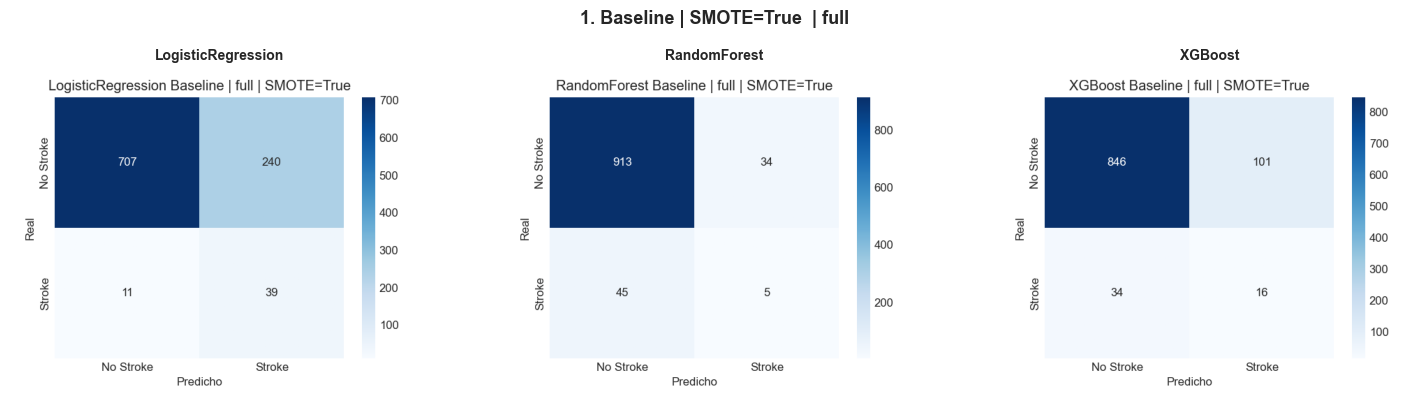

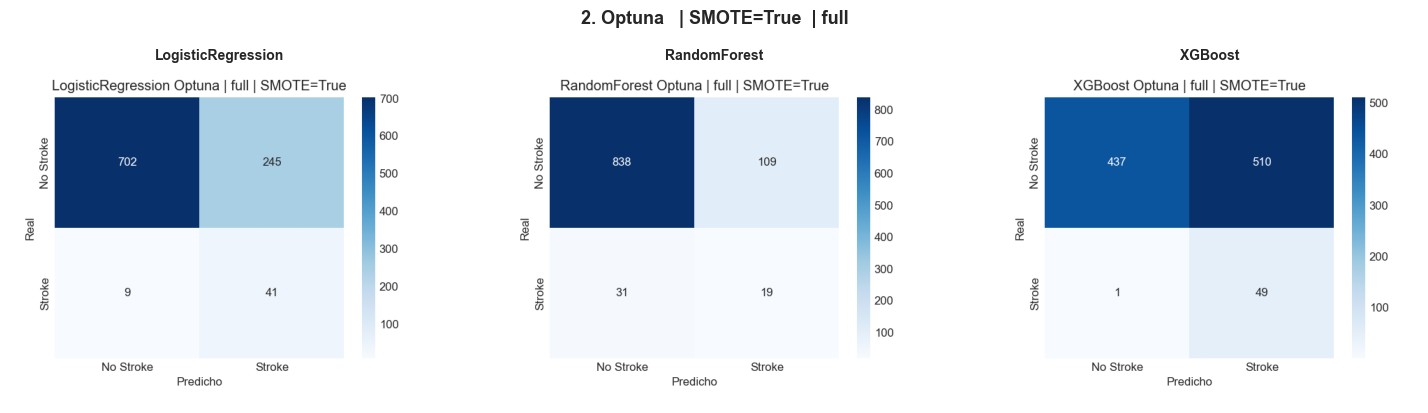

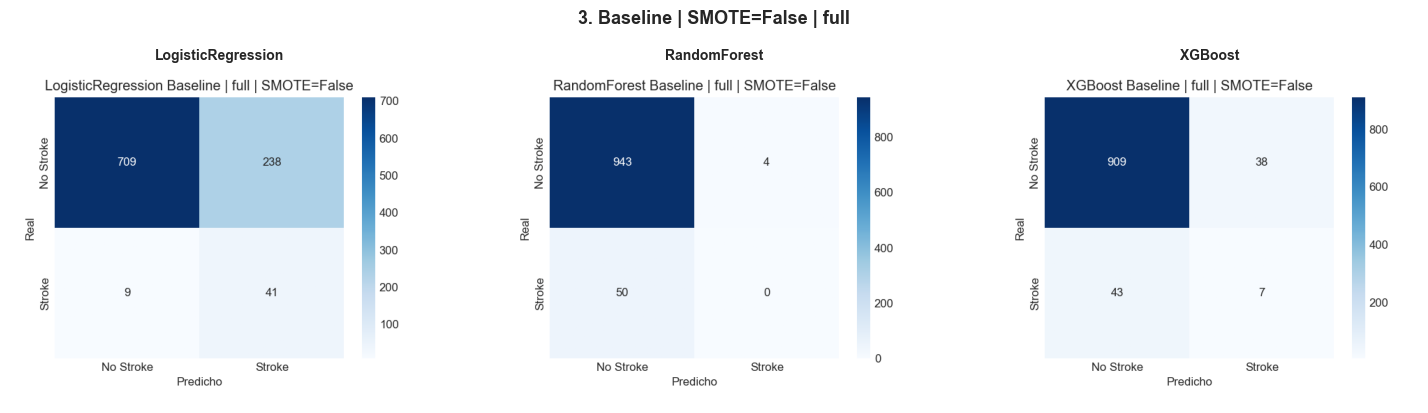

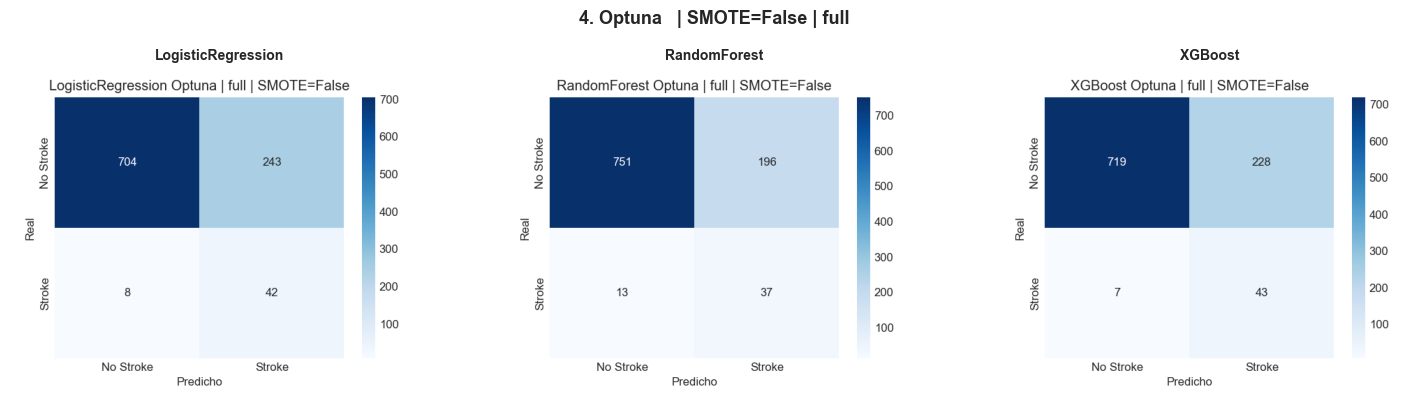

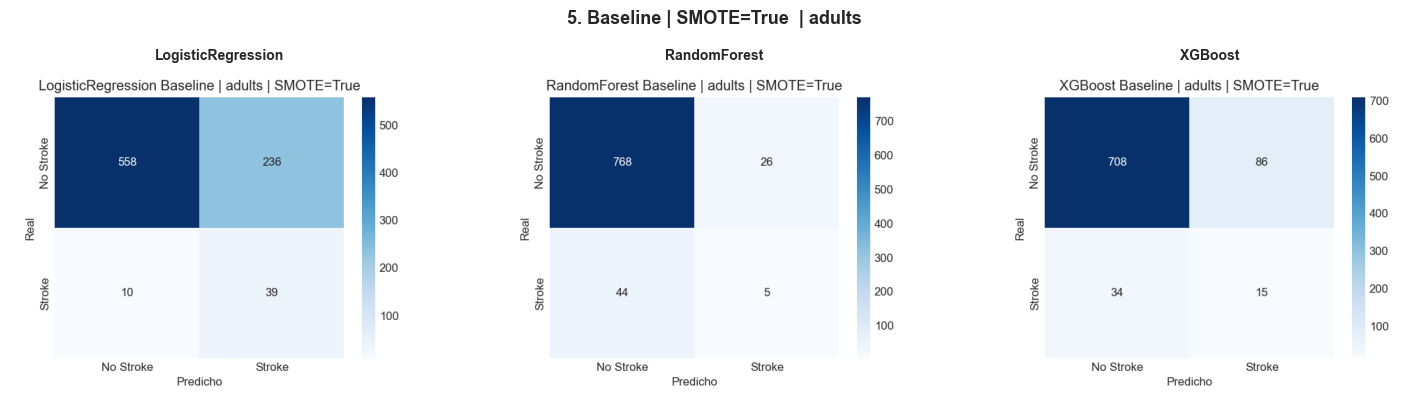

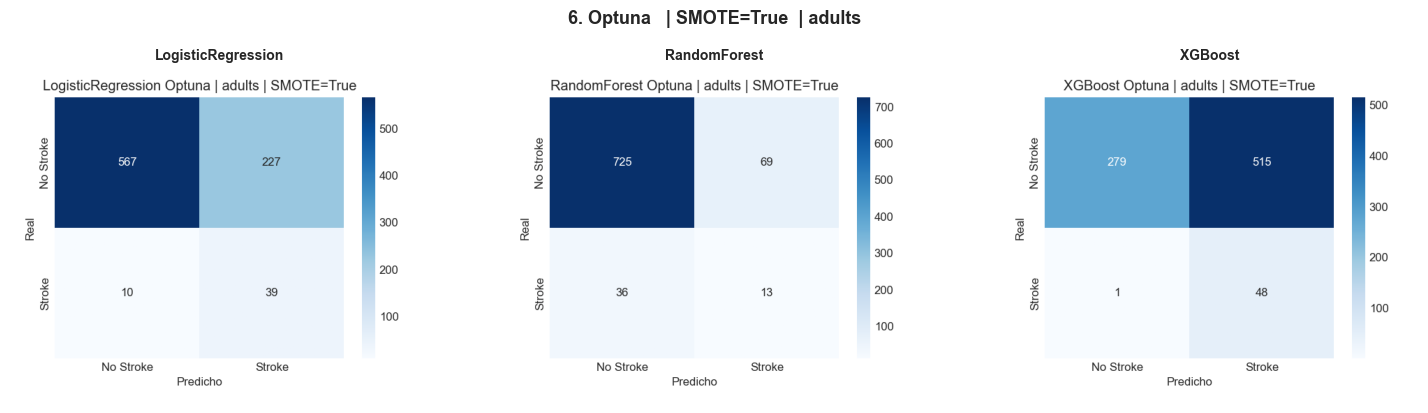

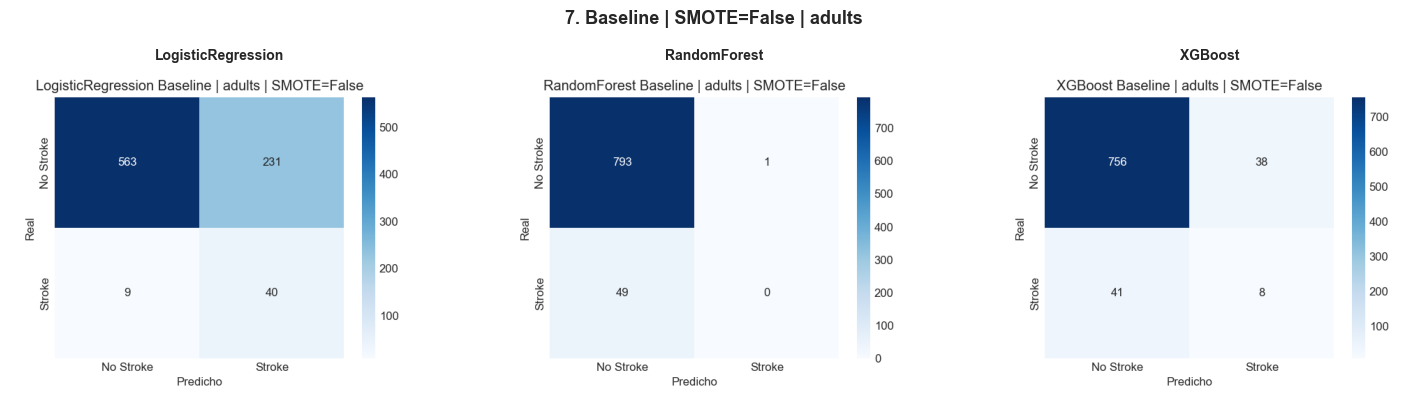

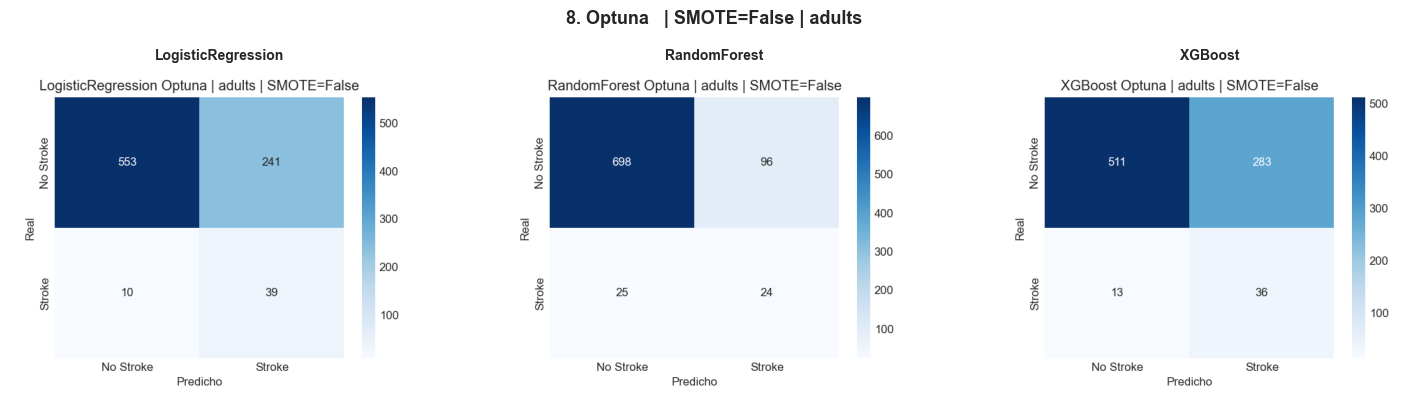

In [14]:
# Grupos ordenados según el requisito
CM_GROUPS = [
    {"tipo": "baseline", "smote": True,  "dataset": "full",   "label": "1. Baseline | SMOTE=True  | full"},
    {"tipo": "optuna",   "smote": True,  "dataset": "full",   "label": "2. Optuna   | SMOTE=True  | full"},
    {"tipo": "baseline", "smote": False, "dataset": "full",   "label": "3. Baseline | SMOTE=False | full"},
    {"tipo": "optuna",   "smote": False, "dataset": "full",   "label": "4. Optuna   | SMOTE=False | full"},
    {"tipo": "baseline", "smote": True,  "dataset": "adults", "label": "5. Baseline | SMOTE=True  | adults"},
    {"tipo": "optuna",   "smote": True,  "dataset": "adults", "label": "6. Optuna   | SMOTE=True  | adults"},
    {"tipo": "baseline", "smote": False, "dataset": "adults", "label": "7. Baseline | SMOTE=False | adults"},
    {"tipo": "optuna",   "smote": False, "dataset": "adults", "label": "8. Optuna   | SMOTE=False | adults"},
]

MODEL_NAMES = ["LogisticRegression", "RandomForest", "XGBoost"]
N_MODELS = len(MODEL_NAMES)

for group in CM_GROUPS:
    fig, axes = plt.subplots(1, N_MODELS, figsize=(5 * N_MODELS, 4))
    fig.suptitle(group["label"], fontsize=13, fontweight="bold", y=1.02)

    for ax, model_name in zip(axes, MODEL_NAMES):
        tipo   = group["tipo"]
        smote  = group["smote"]
        dset   = group["dataset"]

        suffix = "optuna" if tipo == "optuna" else "baseline"
        cm_path = assets_v3_dir / f"cm_{model_name}_{suffix}_{dset}_smote={smote}.png"

        if cm_path.exists():
            img = plt.imread(str(cm_path))
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(model_name, fontsize=10, fontweight="bold")
        else:
            ax.text(0.5, 0.5, f"No encontrado:\n{cm_path.name}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

---
## 10 · Validación estadística entre modelos

Comparamos si las diferencias de rendimiento entre grupos de experimentos son  
estadísticamente significativas.

In [15]:
df_results = pd.DataFrame(results)
print(f"Total de experimentos registrados: {len(df_results)}")

# ── Tabla ranking completo de experimentos ───────────────────────────────────
df_ranking = df_results.copy()

df_ranking["score"] = (df_ranking["auc"] * 0.6) + (df_ranking["recall"] * 0.4)

df_ranking["overfit_flag"] = df_ranking.apply(
    lambda r: "⚠️" if abs(r.get("overfitting_diff_auc", 0)) > 0.05 else "✅", axis=1
)

df_ranking = df_ranking.sort_values("score", ascending=False).reset_index(drop=True)
df_ranking.index += 1

cols_show  = ["modelo", "dataset", "smote", "tipo", "auc", "recall", "f1", "precision", "score", "overfit_flag"]
cols_exist = [c for c in cols_show if c in df_ranking.columns]

df_display = df_ranking[cols_exist].copy()
df_display["smote"] = df_display["smote"].map({True: "✓", False: "✗"})
df_display = df_display.rename(columns={
    "modelo":       "Modelo",
    "dataset":      "Dataset",
    "smote":        "SMOTE",
    "tipo":         "Tipo",
    "auc":          "AUC-ROC 🎯",
    "recall":       "Recall 🎯",
    "f1":           "F1",
    "precision":    "Precision",
    "score":        "Score",
    "overfit_flag": "Overfit",
})

def highlight_top(s):
    styles = []
    for i in range(len(s)):
        rank = i + 1
        if rank <= 3:
            styles.append("background-color: #d4edda; color: #155724; font-weight: bold")
        elif rank <= 8:
            styles.append("background-color: #fff3cd; color: #856404")
        else:
            styles.append("")
    return styles

def highlight_overfit(val):
    if val == "⚠️":
        return "background-color: #f8d7da; color: #721c24"
    return "background-color: #d4edda; color: #155724"

styled = (
    df_display.style
    .apply(highlight_top, subset=["Score"])
    .applymap(highlight_overfit, subset=["Overfit"])
    .format({"AUC-ROC 🎯": "{:.4f}", "Recall 🎯": "{:.4f}", "F1": "{:.4f}", "Precision": "{:.4f}", "Score": "{:.4f}"})
    .set_caption("🏆 Ranking de experimentos — Score = AUC×0.6 + Recall×0.4")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("margin-bottom", "8px")]},
        {"selector": "th",      "props": [("background-color", "#f8f9fa"), ("font-size", "12px"), ("text-align", "center")]},
        {"selector": "td",      "props": [("text-align", "center"), ("font-size", "12px")]},
    ])
)

print(f"{'='*65}")
print(f"  RANKING COMPLETO — {len(df_ranking)} experimentos")
print(f"  Score = AUC×0.6 + Recall×0.4  |  ⚠️ = overfitting ΔAUC > 0.05   | ✅= overfitting ΔAUC ≤ 0.05")
print(f"{'='*65}")
display(styled)

print(f"\n🥇 Mejor modelo: {df_ranking.iloc[0]['modelo']} | {df_ranking.iloc[0]['dataset']} | SMOTE={df_ranking.iloc[0]['smote']} | {df_ranking.iloc[0]['tipo']}")
print(f"   AUC-ROC: {df_ranking.iloc[0]['auc']:.4f} | Recall: {df_ranking.iloc[0]['recall']:.4f} | Score: {df_ranking.iloc[0]['score']:.4f}")

Total de experimentos registrados: 24
  RANKING COMPLETO — 24 experimentos
  Score = AUC×0.6 + Recall×0.4  |  ⚠️ = overfitting ΔAUC > 0.05   | ✅= overfitting ΔAUC ≤ 0.05


,Modelo,Dataset,SMOTE,Tipo,AUC-ROC 🎯,Recall 🎯,F1,Precision,Score,Overfit
1,XGBoost,full,✓,optuna,0.8082,0.9800,0.1609,0.0877,0.8769,✅
2,XGBoost,adults,✓,optuna,0.8054,0.9796,0.1569,0.0853,0.8751,✅
3,XGBoost,full,✗,optuna,0.8541,0.8600,0.2679,0.1587,0.8565,✅
4,LogisticRegression,full,✗,optuna,0.8415,0.8400,0.2507,0.1474,0.8409,✅
5,LogisticRegression,full,✓,optuna,0.8410,0.8200,0.2440,0.1434,0.8326,✅
6,LogisticRegression,full,✗,baseline,0.8406,0.8200,0.2492,0.1470,0.8324,✅
7,LogisticRegression,adults,✗,baseline,0.8332,0.8163,0.2500,0.1476,0.8264,✅
8,LogisticRegression,adults,✓,baseline,0.8389,0.7959,0.2407,0.1418,0.8217,✅
9,LogisticRegression,adults,✓,optuna,0.8352,0.7959,0.2476,0.1466,0.8195,✅
10,LogisticRegression,adults,✗,optuna,0.8304,0.7959,0.2371,0.1393,0.8166,✅



🥇 Mejor modelo: XGBoost | full | SMOTE=True | optuna
   AUC-ROC: 0.8082 | Recall: 0.9800 | Score: 0.8769


### 10.1 · Wilcoxon Signed-Rank — Baseline vs Optuna
**H0**: No hay diferencia significativa en AUC-ROC entre Baseline y Optuna  
**H1**: Optuna mejora significativamente el AUC-ROC  
Se rechaza H0 si p-value < 0.05

In [16]:
print("WILCOXON SIGNED-RANK — Baseline vs Optuna")
print("-" * 60)

for metric in ["auc", "recall", "f1"]:
    baseline_scores = df_results[df_results["tipo"] == "baseline"][metric].values
    optuna_scores   = df_results[df_results["tipo"] == "optuna"][metric].values

    # Alinear longitudes
    min_len = min(len(baseline_scores), len(optuna_scores))
    baseline_scores = baseline_scores[:min_len]
    optuna_scores   = optuna_scores[:min_len]

    try:
        stat, p = wilcoxon(baseline_scores, optuna_scores)
        mejor = "Optuna" if optuna_scores.mean() > baseline_scores.mean() else "Baseline"
        icono = "🎯" if metric in ("auc", "recall") else "  "
        print(f"  {icono} {metric.upper()}:")
        print(f"       Baseline: {baseline_scores.mean():.4f} | Optuna: {optuna_scores.mean():.4f}")
        print(f"       W={stat:.3f} | p-value={p:.6f}")
        print(f"       {'✅ Diferencia significativa' if p < 0.05 else '❌ Sin diferencia significativa'} | Mejor: {mejor}\n")
    except Exception as e:
        print(f"  {metric.upper()}: No calculable — {e}\n")

WILCOXON SIGNED-RANK — Baseline vs Optuna
------------------------------------------------------------
  🎯 AUC:
       Baseline: 0.8003 | Optuna: 0.8256
       W=5.000 | p-value=0.004883
       ✅ Diferencia significativa | Mejor: Optuna

  🎯 RECALL:
       Baseline: 0.3620 | Optuna: 0.7234
       W=2.000 | p-value=0.002930
       ✅ Diferencia significativa | Mejor: Optuna

     F1:
       Baseline: 0.1601 | Optuna: 0.2265
       W=17.000 | p-value=0.088379
       ❌ Sin diferencia significativa | Mejor: Optuna



### 10.2 · T-test — Full vs Adults
**H0**: El AUC-ROC medio es igual entrenando con Full o Adults  
**H1**: Hay diferencia significativa entre los datasets  
Se rechaza H0 si p-value < 0.05

In [17]:
print("T-TEST — Full vs Adults")
print("-" * 60)

for metric in ["auc", "recall", "f1"]:
    full_scores   = df_results[df_results["dataset"] == "full"][metric].values
    adults_scores = df_results[df_results["dataset"] == "adults"][metric].values
    stat, p = ttest_ind(full_scores, adults_scores)
    mejor = "Adults" if adults_scores.mean() > full_scores.mean() else "Full"
    icono = "🎯" if metric in ("auc", "recall") else "  "
    print(f"  {icono} {metric.upper()}: Full={full_scores.mean():.4f} | Adults={adults_scores.mean():.4f}")
    print(f"       t={stat:.4f} | p-value={p:.6f}")
    print(f"       {'✅ Diferencia significativa' if p < 0.05 else '❌ Sin diferencia significativa'} | Mejor: {mejor}\n")

T-TEST — Full vs Adults
------------------------------------------------------------
  🎯 AUC: Full=0.8228 | Adults=0.8031
       t=1.7829 | p-value=0.088413
       ❌ Sin diferencia significativa | Mejor: Full

  🎯 RECALL: Full=0.5650 | Adults=0.5204
       t=0.3172 | p-value=0.754076
       ❌ Sin diferencia significativa | Mejor: Full

     F1: Full=0.1947 | Adults=0.1920
       t=0.0854 | p-value=0.932725
       ❌ Sin diferencia significativa | Mejor: Full



### 10.3 · T-test — SMOTE=True vs SMOTE=False
**H0**: SMOTE no mejora significativamente el AUC-ROC ni el Recall  
**H1**: SMOTE produce mejoras estadísticamente significativas  
Se rechaza H0 si p-value < 0.05

In [18]:
print("T-TEST — SMOTE=True vs SMOTE=False")
print("-" * 60)

for metric in ["auc", "recall", "f1"]:
    smote_true  = df_results[df_results["smote"] == True][metric].values
    smote_false = df_results[df_results["smote"] == False][metric].values
    stat, p = ttest_ind(smote_true, smote_false)
    mejor = "SMOTE=True" if smote_true.mean() > smote_false.mean() else "SMOTE=False"
    icono = "🎯" if metric in ("auc", "recall") else "  "
    print(f"  {icono} {metric.upper()}: SMOTE=True={smote_true.mean():.4f} | SMOTE=False={smote_false.mean():.4f}")
    print(f"       t={stat:.4f} | p-value={p:.6f}")
    print(f"       {'✅ Diferencia significativa' if p < 0.05 else '❌ Sin diferencia significativa'} | Mejor: {mejor}\n")

T-TEST — SMOTE=True vs SMOTE=False
------------------------------------------------------------
  🎯 AUC: SMOTE=True=0.8105 | SMOTE=False=0.8154
       t=-0.4160 | p-value=0.681458
       ❌ Sin diferencia significativa | Mejor: SMOTE=False

  🎯 RECALL: SMOTE=True=0.5521 | SMOTE=False=0.5333
       t=0.1330 | p-value=0.895413
       ❌ Sin diferencia significativa | Mejor: SMOTE=True

     F1: SMOTE=True=0.1940 | SMOTE=False=0.1927
       t=0.0431 | p-value=0.966022
       ❌ Sin diferencia significativa | Mejor: SMOTE=True



### 10.4 · McNemar — Comparación directa de los dos mejores modelos
**H0**: Los dos mejores modelos cometen los mismos errores  
**H1**: Los errores son estadísticamente distintos  
Se rechaza H0 si p-value < 0.05

In [19]:
print("McNEMAR — Comparación de los 2 mejores modelos por AUC-ROC")
print("-" * 65)

top2 = df_results.sort_values("auc", ascending=False).head(2)
print("\nTop 2 modelos por AUC-ROC:")
display(top2[["modelo", "dataset", "smote", "tipo", "auc", "recall"]])

row1 = top2.iloc[0]
row2 = top2.iloc[1]

# Recuperar pipelines ya entrenados
key1 = f"{row1['modelo']}_{row1['dataset']}_smote={row1['smote']}"
key2 = f"{row2['modelo']}_{row2['dataset']}_smote={row2['smote']}"

if key1 not in trained_pipelines or key2 not in trained_pipelines:
    print("⚠️ No se encontraron los pipelines entrenados. Asegúrate de haber ejecutado run_optuna_experiment.")
else:
    # Usar el mismo test set (del modelo con mejor AUC)
    X_test_shared = trained_pipelines[key1]["X_test"]
    y_test_shared = trained_pipelines[key1]["y_test"]

    pipe1 = trained_pipelines[key1]["pipeline"]
    pipe2 = trained_pipelines[key2]["pipeline"]

    # Alinear columnas por si los datasets difieren
    common_cols = [c for c in X_test_shared.columns if c in pipe2.feature_names_in_] \
                  if hasattr(pipe2, "feature_names_in_") else X_test_shared.columns

    pred1 = pipe1.predict(X_test_shared)
    pred2 = pipe2.predict(X_test_shared[common_cols])

    y_true = y_test_shared.values
    ambos_ok  = int(np.sum((pred1 == y_true) & (pred2 == y_true)))
    solo_m1   = int(np.sum((pred1 == y_true) & (pred2 != y_true)))
    solo_m2   = int(np.sum((pred1 != y_true) & (pred2 == y_true)))
    ambos_mal = int(np.sum((pred1 != y_true) & (pred2 != y_true)))

    tabla = np.array([[ambos_ok, solo_m1], [solo_m2, ambos_mal]])
    print(f"\n  Ambos correctos              : {ambos_ok}")
    print(f"  Solo {row1['modelo'][:15]:15s} : {solo_m1}")
    print(f"  Solo {row2['modelo'][:15]:15s} : {solo_m2}")
    print(f"  Ambos incorrectos            : {ambos_mal}")

    result = mcnemar(tabla, exact=False, correction=True)
    print(f"\n  Chi2-statistic : {result.statistic:.4f}")
    print(f"  p-value        : {result.pvalue:.6f}")
    print(f"  Resultado      : {'✅ Los modelos difieren significativamente' if result.pvalue < 0.05 else '❌ Los modelos no difieren significativamente'}")

McNEMAR — Comparación de los 2 mejores modelos por AUC-ROC
-----------------------------------------------------------------

Top 2 modelos por AUC-ROC:


,modelo,dataset,smote,tipo,auc,recall
17,XGBoost,full,False,optuna,0.8541,0.86
15,LogisticRegression,full,False,optuna,0.8415,0.84



  Ambos correctos              : 729
  Solo XGBoost         : 33
  Solo LogisticRegress : 17
  Ambos incorrectos            : 218

  Chi2-statistic : 4.5000
  p-value        : 0.033895
  Resultado      : ✅ Los modelos difieren significativamente


---
## 11 ·Registro de los 3 mejores modelos en MLFlow (Ictus_Project)

In [ ]:
# ════════════════════════════════════════════════════════════════
#  REGISTRO DE LOS 3 MEJORES MODELOS EN MLFLOW (Ictus_Project)
#  · XGBoost          → full | smote=False | optuna  (fijo)
#  · LogisticRegression → full | smote=False | optuna  (fijo)
#  · RandomForest      → mejor score entre sus 8 variantes (auto)
# ════════════════════════════════════════════════════════════════
import shutil

# ── PROTECCIÓN CONTRA DUPLICADOS ────────────────────────────────
runs_existing = mlflow.search_runs(experiment_names=["Ictus_Project"])
if len(runs_existing) >= 3:
    print("⚠️  Los 3 mejores ya están registrados en Ictus_Project. Omitiendo.")
    print(runs_existing[["run_id", "tags.model_type", "metrics.auc", "metrics.score"]].to_string(index=False))
else:
    # ── 1. Identificar el mejor RandomForest ────────────────────
    df_res = pd.DataFrame(results).copy()
    df_res["score"] = df_res["auc"] * 0.6 + df_res["recall"] * 0.4

    best_rf_row = (
        df_res[df_res["modelo"] == "RandomForest"]
        .sort_values("score", ascending=False)
        .iloc[0]
    )
    rf_dataset = best_rf_row["dataset"]
    rf_smote   = best_rf_row["smote"]
    rf_tipo    = best_rf_row["tipo"]
    rf_suffix  = "optuna" if rf_tipo == "optuna" else "baseline"

    print(f"Mejor RandomForest → dataset={rf_dataset} | smote={rf_smote} | tipo={rf_tipo}")
    print(f"AUC={best_rf_row['auc']:.4f} | Recall={best_rf_row['recall']:.4f} | Score={best_rf_row['score']:.4f}\n")

    # ── 2. Los 3 modelos a registrar (hardcoded + RF dinámico) ──
    best_three = [
        {
            "modelo":    "XGBoost",
            "dataset":   "full",
            "smote":     False,
            "tipo":      "optuna",
            "suffix":    "optuna",
            "auc":       df_res.query("modelo=='XGBoost' and dataset=='full' and smote==False and tipo=='optuna'")["auc"].values[0],
            "recall":    df_res.query("modelo=='XGBoost' and dataset=='full' and smote==False and tipo=='optuna'")["recall"].values[0],
            "f1":        df_res.query("modelo=='XGBoost' and dataset=='full' and smote==False and tipo=='optuna'")["f1"].values[0],
            "precision": df_res.query("modelo=='XGBoost' and dataset=='full' and smote==False and tipo=='optuna'")["precision"].values[0],
        },
        {
            "modelo":    "LogisticRegression",
            "dataset":   "full",
            "smote":     False,
            "tipo":      "optuna",
            "suffix":    "optuna",
            "auc":       df_res.query("modelo=='LogisticRegression' and dataset=='full' and smote==False and tipo=='optuna'")["auc"].values[0],
            "recall":    df_res.query("modelo=='LogisticRegression' and dataset=='full' and smote==False and tipo=='optuna'")["recall"].values[0],
            "f1":        df_res.query("modelo=='LogisticRegression' and dataset=='full' and smote==False and tipo=='optuna'")["f1"].values[0],
            "precision": df_res.query("modelo=='LogisticRegression' and dataset=='full' and smote==False and tipo=='optuna'")["precision"].values[0],
        },
        {
            "modelo":    "RandomForest",
            "dataset":   rf_dataset,
            "smote":     rf_smote,
            "tipo":      rf_tipo,
            "suffix":    rf_suffix,
            "auc":       best_rf_row["auc"],
            "recall":    best_rf_row["recall"],
            "f1":        best_rf_row["f1"],
            "precision": best_rf_row["precision"],
        },
    ]

    # ── 3. Registrar en MLflow (los 3 mejores van a Ictus_Project) ──
    mlflow.set_experiment(EXPERIMENT_NAME)

    for m in best_three:
        pipeline_key = f"{m['modelo']}_{m['dataset']}_smote={m['smote']}"
        run_name     = f"{AUTHOR}_{m['modelo']}_BEST_{m['dataset']}_smote={m['smote']}"
        score        = round(m["auc"] * 0.6 + m["recall"] * 0.4, 4)

        print(f"  → {m['modelo']} | {m['dataset']} | smote={m['smote']} | {m['tipo']}")

        with mlflow.start_run(run_name=run_name):
            mlflow.log_metrics({
                "auc":       m["auc"],
                "recall":    m["recall"],
                "f1":        m["f1"],
                "precision": m["precision"],
                "score":     score,
            })
            mlflow.set_tags({
                "author":          AUTHOR,
                "dataset_version": m["dataset"],
                "use_smote":       str(m["smote"]),
                "model_type":      m["modelo"],
                "optimization":    m["tipo"],
                "selection":       "best_per_model_type",
            })

            # Loguear pipeline si está disponible
            if pipeline_key in trained_pipelines:
                pipe = trained_pipelines[pipeline_key]["pipeline"]
                mlflow.sklearn.log_model(pipe, artifact_path=f"best_{m['modelo']}")
                print(f"    ✓ Modelo logueado")
            else:
                print(f"    ⚠️  Pipeline no disponible para key: {pipeline_key} — solo métricas y tags")

            # Copiar CM de assets/v3/ → assets/ y loguear
            cm_src  = assets_v3_dir / f"cm_{m['modelo']}_{m['suffix']}_{m['dataset']}_smote={m['smote']}.png"
            cm_dest = assets_dir    / f"cm_{m['modelo']}_{m['suffix']}_{m['dataset']}_smote={m['smote']}.png"

            if cm_src.exists():
                shutil.copy(cm_src, cm_dest)
                mlflow.log_artifact(str(cm_dest), artifact_path="confusion_matrix")
                print(f"    ✓ CM copiada a assets/ y logueada")
            else:
                print(f"    ⚠️  CM no encontrada: {cm_src.name}")

        print(f"    ✓ Run: {run_name}\n")

    print("✅ 3 mejores modelos registrados en:", EXPERIMENT_BEST)
    print(f"✅ Matrices de confusión en: {assets_dir}")

Mejor RandomForest → dataset=full | smote=False | tipo=optuna
AUC=0.8333 | Recall=0.7400 | Score=0.7960

  → XGBoost | full | smote=False | optuna


---
## 12 · Comparativa de resultados

In [21]:
df_results_sorted = df_results.sort_values("auc", ascending=False).reset_index(drop=True)
df_display = df_results_sorted.copy()
df_display["smote"] = df_display["smote"].map({True: "✓", False: "✗"})
df_display.index += 1

print("=" * 75)
print("  TABLA COMPARATIVA — ordenada por AUC-ROC descendente")
print("=" * 75)
print(df_display.to_string())
print("=" * 75)

print("\n🏆 TOP 5 por AUC-ROC:")
print(df_results_sorted.head(5)[["modelo", "dataset", "smote", "tipo", "auc", "recall", "f1"]].to_string(index=False))

print("\n🎯 TOP 5 por Recall:")
print(df_results_sorted.sort_values("recall", ascending=False).head(5)[
    ["modelo", "dataset", "smote", "tipo", "auc", "recall", "f1"]
].to_string(index=False))

  TABLA COMPARATIVA — ordenada por AUC-ROC descendente
                modelo dataset smote      tipo  overfitting_diff_auc  overfitting_diff_recall  overfitting_diff_f1     auc  recall      f1  precision
1              XGBoost    full     ✗    optuna                0.0327                   0.0087              -0.0043  0.8541  0.8600  0.2679     0.1587
2   LogisticRegression    full     ✗    optuna                0.0051                  -0.0218              -0.0132  0.8415  0.8400  0.2507     0.1474
3   LogisticRegression    full     ✓    optuna                0.0044                   0.0032              -0.0088  0.8410  0.8200  0.2440     0.1434
4   LogisticRegression    full     ✗  baseline                0.0065                  -0.0170              -0.0140  0.8406  0.8200  0.2492     0.1470
5   LogisticRegression  adults     ✓  baseline               -0.0214                  -0.0091               0.0081  0.8389  0.7959  0.2407     0.1418
6   LogisticRegression    full     ✓  baselin

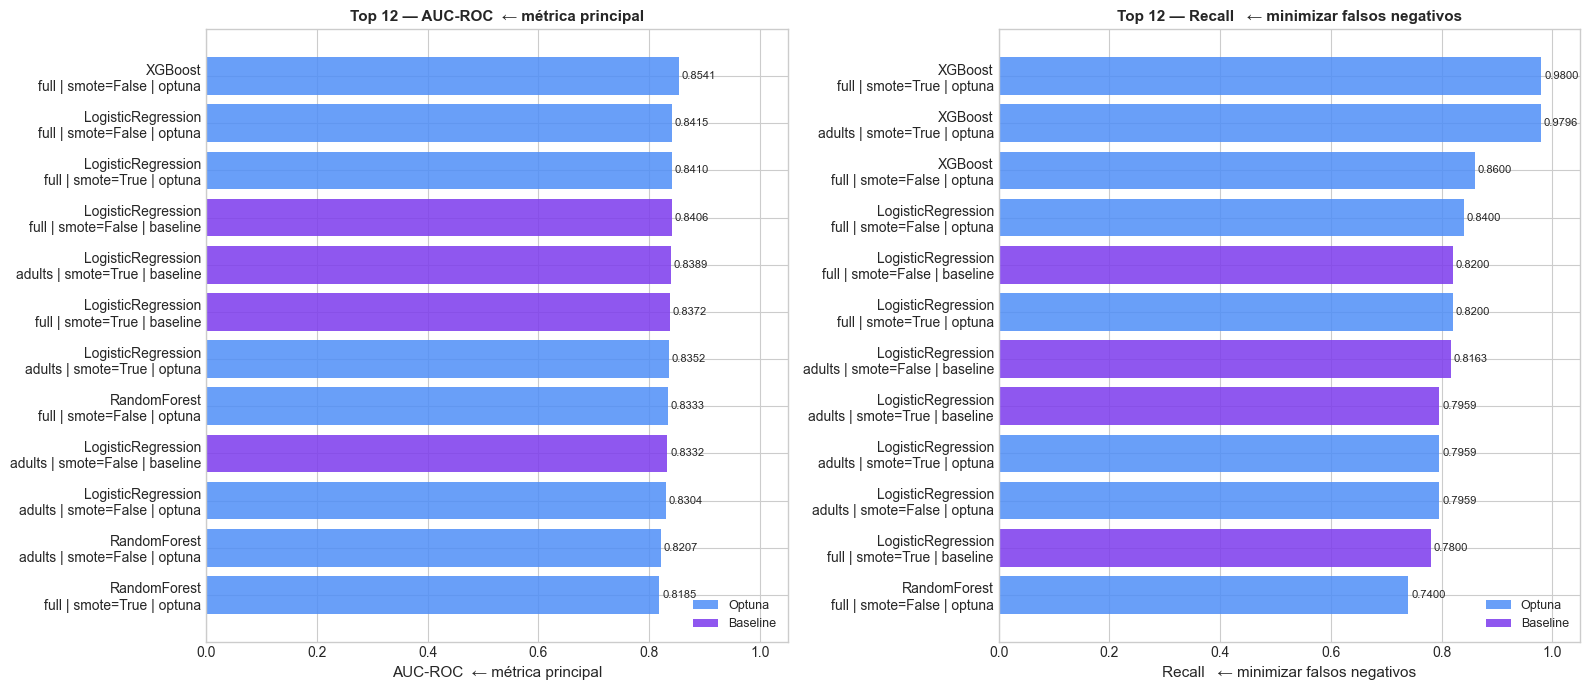

✓ Gráfico guardado: C:\Users\Coder\Documents\Proyectos-Modulo3\Project_8_Equipo1_DataScientist\assets\comparativa_experimentos.png


In [22]:
# Gráfico comparativo — AUC-ROC y Recall
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, metric, label in [
    (axes[0], "auc",    "AUC-ROC  ← métrica principal"),
    (axes[1], "recall", "Recall   ← minimizar falsos negativos")
]:
    df_plot = df_results.copy()
    df_plot["etiqueta"] = (
        df_plot["modelo"] + "\n" +
        df_plot["dataset"] + " | smote=" +
        df_plot["smote"].astype(str) + " | " +
        df_plot["tipo"]
    )
    df_plot = df_plot.sort_values(metric, ascending=False).head(12)

    colors = ["#4f8ef7" if t == "optuna" else "#7c3aed" for t in df_plot["tipo"]]
    bars = ax.barh(df_plot["etiqueta"], df_plot[metric], color=colors, alpha=0.85)
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(f"Top 12 — {label}", fontsize=11, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.invert_yaxis()

    for bar, val in zip(bars, df_plot[metric]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

    legend_elements = [
        Patch(facecolor="#4f8ef7", alpha=0.85, label="Optuna"),
        Patch(facecolor="#7c3aed", alpha=0.85, label="Baseline"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
comp_path = str(assets_dir / "comparativa_experimentos.png")
plt.savefig(comp_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Gráfico guardado: {comp_path}")

---
## 13 · Explicabilidad con SHAP para modelo XGBoost

In [23]:
# import shap

# # Recuperar el pipeline entrenado
# key = "XGBoost_full_smote=False"
# pipeline = trained_pipelines[key]["pipeline"]
# X_test   = trained_pipelines[key]["X_test"]

# # Extraer el preprocesador y el modelo por separado
# preprocessor = pipeline.named_steps["prep"]
# model        = pipeline.named_steps["model"]

# # Transformar X_test con el preprocesador
# X_test_transformed = preprocessor.transform(X_test)

# # Obtener nombres de columnas tras OneHotEncoder
# feature_names = preprocessor.get_feature_names_out()

# # Calcular SHAP values
# explainer   = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test_transformed)

# # ── Gráfico 1: importancia global de features ──────────────
# shap.summary_plot(
#     shap_values, X_test_transformed,
#     feature_names=feature_names,
#     plot_type="bar",
#     show=True
# )

# # ── Gráfico 2: impacto detallado por feature ───────────────
# shap.summary_plot(
#     shap_values, X_test_transformed,
#     feature_names=feature_names,
#     show=True
# )

# # ── Gráfico 3: explicación de un paciente concreto ─────────
# idx = 0  # cambia el índice para ver otro paciente
# shap.waterfall_plot(
#     shap.Explanation(
#         values        = shap_values[idx],
#         base_values   = explainer.expected_value,
#         data          = X_test_transformed[idx],
#         feature_names = feature_names
#     )
# )

In [24]:
# Exportar resultados a CSV
#csv_path = BASE_DIR / "reports" / "experiment_results_v3.csv"
#csv_path.parent.mkdir(parents=True, exist_ok=True)
#df_results.to_csv(csv_path, index=False)
#print(f"✓ Resultados exportados: {csv_path}")
#print(f"  {len(df_results)} experimentos guardados")